# Tutorial 5

Course Instructor: Dr.-Ing. J. Rogelio Guadarrama Olvera
hsa-lecture.ics@xcit.tum.de

Summer Semester 2026

## Notebook Setup

1. Open the VS Code terminal.
2. Create the virtual environment: `python -m venv .venv`
3. Activate it:
* **Mac/Linux:** `source .venv/bin/activate`
* **Windows:** `.\.venv\Scripts\activate`
4. Go to code directory `cd T5/code/`
5. Install dependencies: `pip install -r requirements.txt`

6. Set the Notebook Kernel: Click **Select Kernel** in the top right -> **Python Environments** -> Choose **.venv**.


## Acoustic Sensors and Signal Processing (57 points)

In this tutorial we will refresh some basics of signal processing including correlation, Fast Fourier Transform (FFT) and filtering. All tasks are solvable with Python, Matlab, Octave or Scilab with a slightly varying syntax.

**Note:** You may use any of the above programming languages. However, we strongly recommend using Jupyter Notebooks (python) to solve and visualize all the tutorial. We will only support installation/setup questions related to python.

## 1 Sound Source Localization (8 points)

### Report

**R.1.1 (3 points)** Find the expression to determine the azimuth angle of a sound source for a system with two microphones. Derive the equations shown in the slides of Lecture 3 step by step.

Type here the answer...



**R.1.2 (3 points)** Find the expression to determine the velocity of a target from the pulse duration difference of a radar sensor. Derive the equations shown in the slides of Lecture 3 step by step.




Type here the answer...




**R.1.3 (1 point)** How can we measure the distance to a target?




Type here the answer...




**R.1.4 (1 point)** How can we measure the speed of a moving target?




Type here the answer...




## 2 Fast Fourier Transform (8 points)

### Tasks

**T.2.1** Create a signal consisting of the sum of two sine waves using a sample frequency of 1000Hz, one with amplitude of 1 and frequency of 50 Hz and the other with amplitude 0.5 and frequency 120 Hz. Plot the signal over a time slot of 2s.




In [ ]:
# type here the code...



**T.2.2** Run a FFT (Fast Fourier transform) on the signal from T.2.1 and plot it. Normalize the output to 1 and only show positive frequencies.




In [ ]:
# type here the code...



**T.2.3** Add random noise to the signal from T.2.1 and plot the signal again.




In [ ]:
# type here the code...



**T.2.4** Run the FFT on the noisy signal from T.2.3 and plot it.




In [ ]:
# type here the code...



### Report

**R2.1 (2 points)** Is it possible to implement FFT to an online data streaming? Why?




Type here the answer...




**R2.2 (2 points)** How can you use FFT in signal processing?




Type here the answer...




**R2.3 (2 points)** Deliver the code used to generate the signals and plots?




Type here the code...





## 3 Audio Correlation (8 points)

### Tasks

**T.3.1** Load the ‘chimes.wav’ file into the workspace and isolate one of its channels.

- Plot the signal with a reasonable time scale.
- If you have speakers/headphones: try to output the audio signal.




In [ ]:
# type here the code...



**T.3.2** Run an FFT on the audio signal from T.3.1 and plot it.




In [ ]:
# type here the code...



**T.3.3** Generate a left and a right channel from the signal of T.3.1 and add a delay and scaling factor to one of them. Make the delay and scaling factors variable.




In [ ]:
# type here the code...





**T.3.4** Plot the two signals in the same figure.




In [ ]:
# type here the code...



**T.3.5** If you have speakers/headphones: listen to the signals and find parameters at which stereo localization works for you.




In [ ]:
# type here the code...





**T.3.6** Run cross-correlation on both signals and plot the correlation against delay.




In [ ]:
# type here the code...



**T.3.7** Add noise with a normal distribution to both channels.




In [ ]:
# type here the code...





**T.3.8** Run cross-correlation on the noisy signals and plot.




In [ ]:
# type here the code...



### Report

**R.3.1 (2 point)** Is it possible to implement the cross-correlation to an online data streaming? Why?




Type here the answer...




**R.3.2 (2 point)** If you answered “no” to R.3.1, how would you work around to use it to identify the interaural time delay?




Type here the answer...




**R.3.3 (4 points)** Deliver the code to generate the signals and the plots (T.3.1 - T.3.8).






## 4 Signal Filtering (33 points)

### Tasks

**T.4.1** Create a signal consisting of two sine waves, one with amplitude of 1 and a frequency of 50 Hz and one with amplitude 0.5 and frequency of 500 Hz using a sample frequency of 10,000 Hz.




In [3]:
# type here the code...
import numpy as np
import matplotlib.pyplot as plt

# Signal 1
frequency_1 = 50
amplitude_1 = 1.0

# Signal 2
frequency_2 = 500
amplitude_2 = 0.5

phase = 0              
sampling_rate = 10000
duration = 0.1         

# Time samples
t = np.arange(0, duration, 1 / sampling_rate)

# Sine wave samples (signal 1 + signal 2)
x = amplitude_1 * np.sin(2 * np.pi * frequency_1 * t + phase) + amplitude_2 * np.sin(2 * np.pi * frequency_2 * t + phase)




**T.4.2** Plot the signal over a time slot of 0.1s.




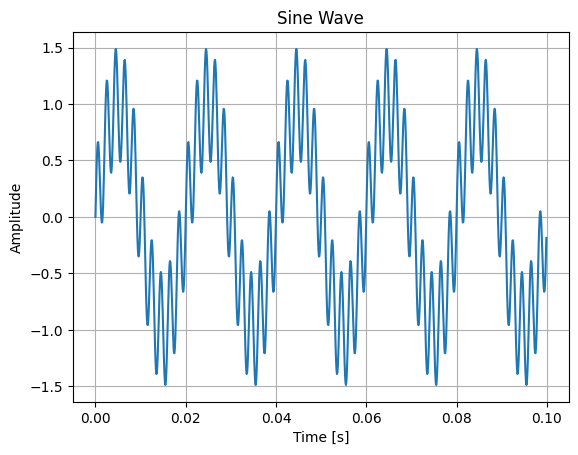

In [4]:

plt.plot(t, x)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Sine Wave")
plt.grid(True)
plt.show()



**T.4.3** Design an analog low-pass passive filter with a cut-off frequency of 50 Hz.

Cut-off frequency:  f_cutoff = 50Hz = 1 / 2*pi*RC -> RC = 1 / 2*pi*50 ≈ 0.00318

Choose for example: R=10kΩ; C=330nF (The ideal Capacitor would ahve 318nF, but this is not commercially available as a part)

Then: f_cutoff = 1 / (2*pi*10000*330*10⁻⁹) ≈ 48.2Hz

So a valid practical design is: R=10kΩ; C=330nF



**T.4.4** Design and implement a first order discrete low-pass filter with cut-off frequency of 50 Hz.




In [5]:
frequency_cutoff_lp = 50
t_s = 1 / sampling_rate
time_constant = 1 / (2*np.pi*frequency_cutoff_lp)

#Filter coefficient
alpha = t_s / (time_constant + t_s)
print(alpha)

# The calculated alpha is then used in the recursive low-pass filter equation:
# y[n] = alpha*x[n] + (1-alpha)*y[n-1]

0.030459027951421226




**T.4.5** Apply the filter from T.4.4 to the signal created in T.4.1. Plot again the signal after filtering.




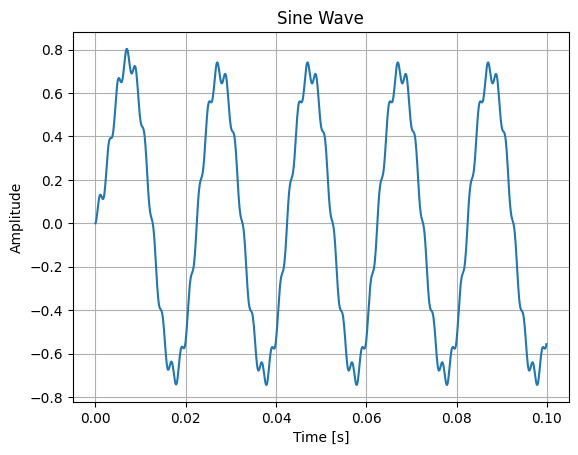

In [6]:
#Initialize
y = np.zeros_like(x)
y[0] = x[0]

#Apply filter
for n in range(1, len(x)):
    y[n] = alpha * x[n] + (1 - alpha) * y[n - 1]

plt.plot(t, y)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Sine Wave")
plt.grid(True)
plt.show()



**T.4.6** Design an analog high-pass passive filter with a cut-off frequency of 500 Hz.




Cut-off frequency:  f_cutoff = 500Hz = 1 / 2*pi*RC -> RC = 1 / 2*pi*500 ≈ 0.000318

Choose for example: R=10kΩ; C=33nF (The ideal Capacitor would have 31.8nF, but this is not commercially available as a part)

Then: f_cutoff = 1 / (2*pi*10000*33*10⁻⁹) ≈ 482Hz

So a valid practical design is: R=10kΩ; C=33nF



**T.4.7** Design and implement a first order discrete high-pass filter with cut-off frequency of 500 Hz.




In [7]:
frequency_cutoff_hp = 500
t_s = 1 / sampling_rate
time_constant = 1 / (2*np.pi*frequency_cutoff_hp)

# Filter coefficient
alpha = time_constant / (time_constant + t_s)
print(alpha)

# The calculated alpha is then used in the recursive high-pass filter equation:
# y[n] = alpha*(y[n-1] + x[n] - x[n-1])

0.7609427763893117




**T.4.8** Apply the filter from T.4.7 to the signal created in T.4.1. Plot again the signal after filtering.




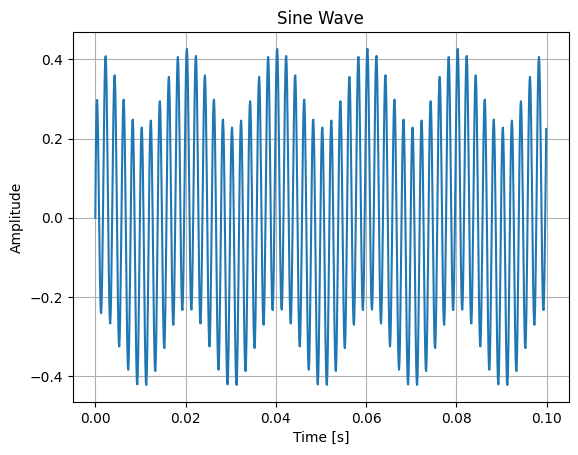

In [8]:
#Initialize
y = np.zeros_like(x)
y[0] = x[0]

#Apply filter
for n in range(1, len(x)):
    y[n] = alpha*(y[n-1] + x[n] - x[n-1])

plt.plot(t, y)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Sine Wave")
plt.grid(True)
plt.show()

**T.4.9** Create another sine wave signal with a frequency of 1,000 Hz using a sample frequency of 10,000 Hz. Then, add it to the signal created in T.4.1.




In [9]:
frequency_3 = 1000
amplitude_3 = 1

x_new = x + amplitude_3* np.sin(2 * np.pi * frequency_3 * t + phase)




**T.4.10** Design an analog band-pass active filter to recover the 500 Hz signal.




Cut-off frequencies: f_low = 400Hz; f_high = 600Hz

f_low = 400Hz = 1 / 2*pi*R1*C1 -> R1C1 = 1 / 2*pi*400 ≈ 0.000398

Choose for example: R1=10kΩ; C1=39nF
Then: f_low = 1 / (2*pi*10000*39*10⁻⁹) ≈ 408Hz

f_high = 600Hz = 1 / 2*pi*R2*C2 -> R2C2 = 1 / 2*pi*600 ≈ 0.000265

Choose for example: R2=10kΩ; C2=27nF
Then: f_high = 1 / (2*pi*10000*27*10⁻⁹) ≈ 589Hz

So a valid practical band pass design is: R1=10kΩ; C1=39nF and R2=10kΩ; C2=27nF

This gives a pass band of approximately 408Hz to 589Hz, so the 500Hz signal passes.



**T.4.11** Design and implement a discrete band-pass filter to recover the 500 Hz signal from the superposed signal.




In [10]:
frequency_cutoff_bph = 400   # lower cut-off frequency
frequency_cutoff_bpl = 600   # upper cut-off frequency

t_s = 1 / sampling_rate

time_constant_bph = 1 / (2*np.pi*frequency_cutoff_bph)
time_constant_bpl = 1 / (2*np.pi*frequency_cutoff_bpl)

# Filter coefficients
alpha_bph = time_constant_bph / (time_constant_bph + t_s)
alpha_bpl = t_s / (time_constant_bpl + t_s)

print(alpha_bph)
print(alpha_bpl)

# The calculated alpha_hp is then used in the recursive high-pass filter equation:
# y_hp[n] = alpha_hp*(y_hp[n-1] + x[n] - x[n-1])

# The calculated alpha_lp is then used in the recursive low-pass filter equation:
# y_bp[n] = y_bp[n-1] + alpha_lp*(y_hp[n] - y_bp[n-1])

0.7991513573351632
0.2737789034256051




**T.4.12** Apply the filter from T.4.11 to the signal created in T.4.9. Plot again the signal after filtering.




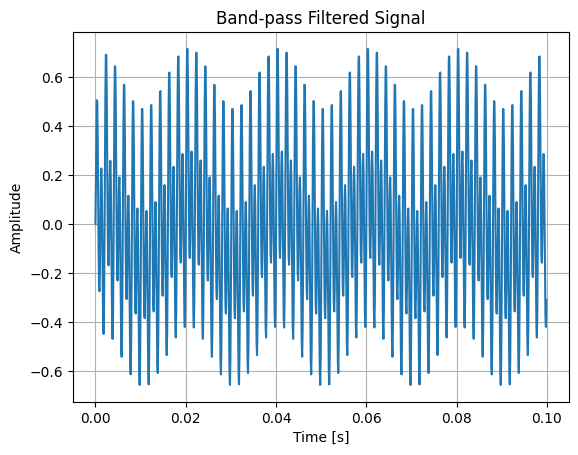

In [ ]:
# Initialize
y_hp = np.zeros_like(x_new)
y = np.zeros_like(x_new)    

y_hp[0] = x_new[0]
y[0] = y_hp[0]

# Apply band-pass filter
for n in range(1, len(x_new)):
    # High-pass part
    y_hp[n] = alpha_bph*(y_hp[n-1] + x_new[n] - x_new[n-1])
    # Low-pass part
    y[n] = y[n-1] + alpha_bpl*(y_hp[n] - y[n-1])

plt.plot(t, y)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Band-pass Filtered Signal")
plt.grid(True)
plt.show()


### Report

**R.4.1 (2 points)** Detail the design process of the filter in T.4.3. Draw the required circuit and calculate the value for the components step by step.




Type here the answer...


**R.4.2 (2 points)** Detail the design process of the filter in T.4.4. Derive the equation to implement the filter step by step on a data stream.




Type here the answer...




**R.4.3 (2 points)** Detail the design process of the filter in T.4.6. Draw the required circuit and calculate the value for the components step by step.




Type here the answer...


**R.4.4 (2 points)** Detail the design process of the filter in T.4.7. Derive the equation to implement the filter step by step on a data stream.




Type here the answer...




**R.4.5 (2 points)** Detail the design process of the filter in T.4.10. Draw the required circuit and calculate the value for the components step by step.




Type here the answer...



**R.4.6 (2 points)** Detail the design process of the filter in T.4.11. Derive the equation to implement the filter step by step on a data stream.




Type here the answer...




**R.4.7 (2 point)** What is the difference between passive and active filters?




Type here the answer...




**R.4.8 (2 point)** What is the difference between FIR and IIR filters?




Type here the answer...




**R.4.9 (2 point)** What is the “order” of a discrete filter?




Type here the answer...




**R.4.10 (2 point)** How could you implement a continuous-time filter in a robotic system?




Type here the answer...




**R.4.11 (2 point)** How could you implement a discrete-time filter in a robotic system?




Type here the answer...




**R.4.12 (3 point)** What are the advantages and disadvantages of analog and digital filters in robotic systems?




Type here the answer...




**R.4.13 (2 point)** Is it possible to make a 1000 Hz Low-Pass filter in a digital system with a sampling rate of 1000 Hz?




Type here the answer...




**R.4.14 (6 points)** Deliver the code to generate the signals and the plots (T.4.1 - T.4.12).


